# Carleton evacuation — MARS

Set `SCENARIO` (1–10) and `RUN_SIMULATION` below, then run all cells.

| # | Scenario |
|---|----------|
| 1 | Instant deploy 06:00; P1/P2 → SW evac (Meadowlands); P3–P7 → NE evac box |
| 2 | P6 +1 h |
| 3 | P6 +2 h |
| 4 | P3 +1 h, P6 +2 h |
| 5 | P3/P4 +1 h, P6 +2 h |
| 6 | P3/P4 +1 h, P6 +1.5 h |
| 7 | Baseline timing; P3/P4 emergency exit |
| 8 | Bronson & University Dr exit blocked; P1/P2 → SW; P3–P7 → Brewer Park |
| 9 | Baseline timing; Bronson blocked + Raven emergency; P1/P2 → Colonel By, P3/P4/P5/P6/P7 → emergency |
| 10 | Baseline timing; base graph; P6 → Colonel By (P1–P3 Colonel By, P4/P5/P7 Bronson) |

**Step 1** — Load the project folder and helpers for running commands.

In [38]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from datetime import datetime
from pathlib import Path

from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "SOHCarletonDrivingBox.csproj").is_file():
    candidate = ROOT / "CarletonDrivingBox"
    if (candidate / "SOHCarletonDrivingBox.csproj").is_file():
        ROOT = candidate

os.chdir(ROOT)

SCRIPTS = ROOT / "scripts"
RESULTS = ROOT / "results"
CONFIGS = ROOT / "configs"
PROJECT = "SOHCarletonDrivingBox.csproj"

sys.path.insert(0, str(SCRIPTS))
from mars_agent_outputs import agent_output_path


def config_arg(config: Path) -> str:
    """POSIX-relative config path for dotnet (works on Windows and Mac)."""
    return config.relative_to(ROOT).as_posix()


def run_cmd(cmd: list[str], *, quiet: bool = False, label: str | None = None) -> None:
    if label:
        print(label, flush=True)
    elif not quiet:
        print("Running:", " ".join(cmd), flush=True)
    completed = subprocess.run(
        cmd,
        cwd=ROOT,
        env={**os.environ, "DOTNET_NOLOGO": "1"},
        capture_output=quiet,
        text=True,
    )
    if completed.returncode != 0:
        details = ""
        if quiet:
            details = "\n" + (completed.stdout or "") + (completed.stderr or "")
        raise RuntimeError(
            f"Command failed ({completed.returncode}): {' '.join(cmd)}{details}"
        )
    if quiet:
        print("  done.", flush=True)


def run_simulation_cmd(cmd: list[str], *, label: str = "Running simulation…") -> subprocess.CompletedProcess:
    """Run MARS with a real console (ProgressBar needs one when console:true)."""
    print(label, flush=True)
    kwargs: dict = {
        "cwd": ROOT,
        "env": {**os.environ, "DOTNET_NOLOGO": "1"},
    }
    if sys.platform == "win32":
        kwargs["creationflags"] = subprocess.CREATE_NEW_CONSOLE
    else:
        kwargs["stdout"] = None
        kwargs["stderr"] = None
    return subprocess.run(cmd, **kwargs)


assert (ROOT / PROJECT).is_file(), f"Open this notebook from {ROOT.name}/"

**Step 2** — Pick the scenario and whether to run a new simulation or reuse existing results.

In [44]:
SCENARIO = 1
RUN_SIMULATION = False
BUILD_FIRST = False
# Independent: regular charts vs road-name congestion heatmap
RUN_ANALYZE = True
RUN_HEATMAP = True
RUN_ROUTES = False

SID = f"{SCENARIO:02d}"
CONFIG = CONFIGS / f"config_scenario_{SID}.json"
OUT_DIR = RESULTS / f"scenario_{SID}"
CSV_PATH = agent_output_path(OUT_DIR, ".csv")
ROUTES_DIR = OUT_DIR / "agent_routes"

assert CONFIG.is_file(), f"Missing config: {CONFIG}"
print(
    f"scenario_{SID}  |  sim={RUN_SIMULATION}  analyze={RUN_ANALYZE}  "
    f"heatmap={RUN_HEATMAP}  |  results: {OUT_DIR.relative_to(ROOT)}/"
)


scenario_01  |  sim=False  analyze=True  heatmap=True  |  results: results\scenario_01/


**Step 3** — Build and run the MARS simulation (skipped when `RUN_SIMULATION` is False).

On **Windows**, MARS opens in a separate console window (required for `console: true` progress output). Jupyter waits until that window closes.

In [45]:
if RUN_SIMULATION:
    if BUILD_FIRST:
        run_cmd(
            ["dotnet", "build", PROJECT, "-v", "q", "/p:NuGetAudit=false", "/clp:ErrorsOnly"],
            quiet=True,
            label="Building…",
        )
    cmd = ["dotnet", "run", "--no-launch-profile", "--project", PROJECT]
    if BUILD_FIRST:
        cmd.insert(2, "--no-build")
    cmd += ["--", config_arg(CONFIG)]
    completed = run_simulation_cmd(cmd, label="Running simulation…")
    if completed.returncode != 0:
        raise RuntimeError(
            f"Simulation failed (exit {completed.returncode}). "
            "Check the MARS console window for errors."
        )
    if not CSV_PATH.is_file():
        raise FileNotFoundError(
            f"Simulation exited OK but CSV missing: {CSV_PATH}"
        )
    stat = CSV_PATH.stat()
    mtime = datetime.fromtimestamp(stat.st_mtime)
    print(
        f"CSV: {CSV_PATH.name}  |  {stat.st_size:,} bytes  |  "
        f"modified {mtime:%Y-%m-%d %H:%M:%S}",
        flush=True,
    )
    print(f"Finished. Results in: {OUT_DIR.relative_to(ROOT)}/", flush=True)
else:
    print("Simulation skipped.")

Simulation skipped.


**Step 4** — Analyze and/or build the congestion heatmap.

- `RUN_ANALYZE = True` — summary charts (evac curve, exits, clearance, …)
- `RUN_HEATMAP = True` — **all campus roads** congestion over time (`heatmap_matrix.png`)
- Turn on either or both. Heatmap alone skips the other charts.


Running: C:\Users\doria\Documents\model-soh\CarletonDrivingBox\.venv\Scripts\python.exe C:\Users\doria\Documents\model-soh\CarletonDrivingBox\scripts\analyze_run.py C:\Users\doria\Documents\model-soh\CarletonDrivingBox\results\scenario_01\CarletonCarDriver.csv
Running: C:\Users\doria\Documents\model-soh\CarletonDrivingBox\.venv\Scripts\python.exe C:\Users\doria\Documents\model-soh\CarletonDrivingBox\scripts\build_heatmap_matrix.py C:\Users\doria\Documents\model-soh\CarletonDrivingBox\results\scenario_01\CarletonCarDriver.csv --dt 10
Running: C:\Users\doria\Documents\model-soh\CarletonDrivingBox\.venv\Scripts\python.exe C:\Users\doria\Documents\model-soh\CarletonDrivingBox\scripts\plot_heatmap.py C:\Users\doria\Documents\model-soh\CarletonDrivingBox\results\scenario_01\heatmap_matrix.csv


### Summary

scenario_id,expected_deployed,baseline_target,completed_trips_geojson,completed_unique_ids_csv,goal_reached_rows_csv,completion_rate_pct,csv_tick_rows,evac_end_s,peak_on_campus,mean_campus_exit_travel_s,median_campus_exit_travel_s,mean_campus_exit_from_t0_s,median_campus_exit_from_t0_s,mean_finish_travel_s,median_finish_travel_s,mean_finish_from_t0_s,median_finish_from_t0_s
01,3200,3200,3200,37619,135529,100.0,19688778,12544,3200,5709.13,5629.0,5770.13,5690.0,6151.74,6089.0,6212.74,6150.0



### metrics.json

{
  "schema_version": 2,
  "framework": "mars",
  "scenario_id": "01",
  "units": {
    "time": "seconds",
    "counts": "vehicles"
  },
  "metrics": {
    "expected_deployed": 3200,
    "baseline_target": 3200,
    "completed_trips": 3200,
    "completed_unique_ids_csv": 37619,
    "goal_reached_rows_csv": 135529,
    "completion_rate_pct": 100.0,
    "csv_tick_rows": 19688778,
    "evac_end_s": 12544,
    "peak_on_campus": 3200,
    "mean_trip_s": 5709.13,
    "median_trip_s": 5629.0,
    "mean_exit_from_t0_s": 5770.13,
    "median_exit_from_t0_s": 5690.0,
    "mean_campus_exit_travel_s": 5709.13,
    "median_campus_exit_travel_s": 5629.0,
    "mean_campus_exit_from_t0_s": 5770.13,
    "median_campus_exit_from_t0_s": 5690.0,
    "mean_finish_travel_s": 6151.74,
    "median_finish_travel_s": 6089.0,
    "mean_finish_from_t0_s": 6212.74,
    "median_finish_from_t0_s": 6150.0,
    "n_trips_timed": 3200
  },
  "lot_deploy_plan": {
    "P1": {
      "schedule_spawns": 100,
      "baseline

### Deployment

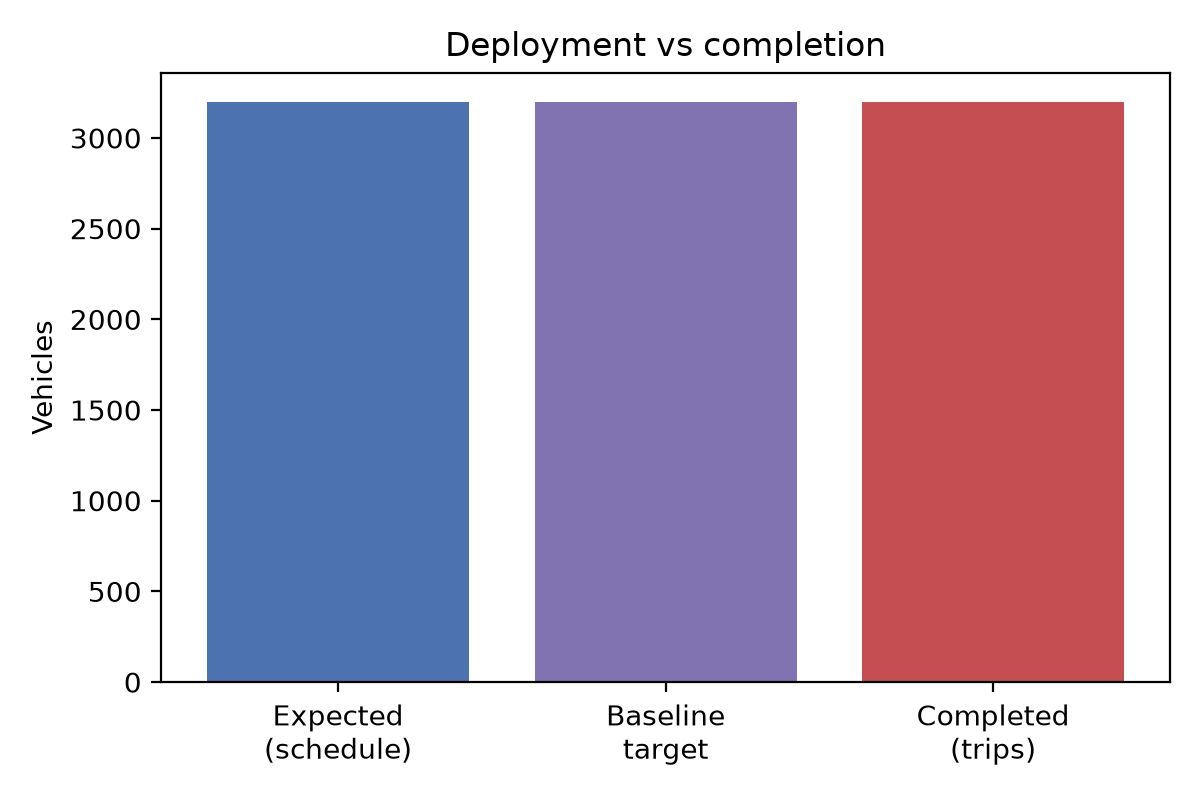

### Evacuation curve

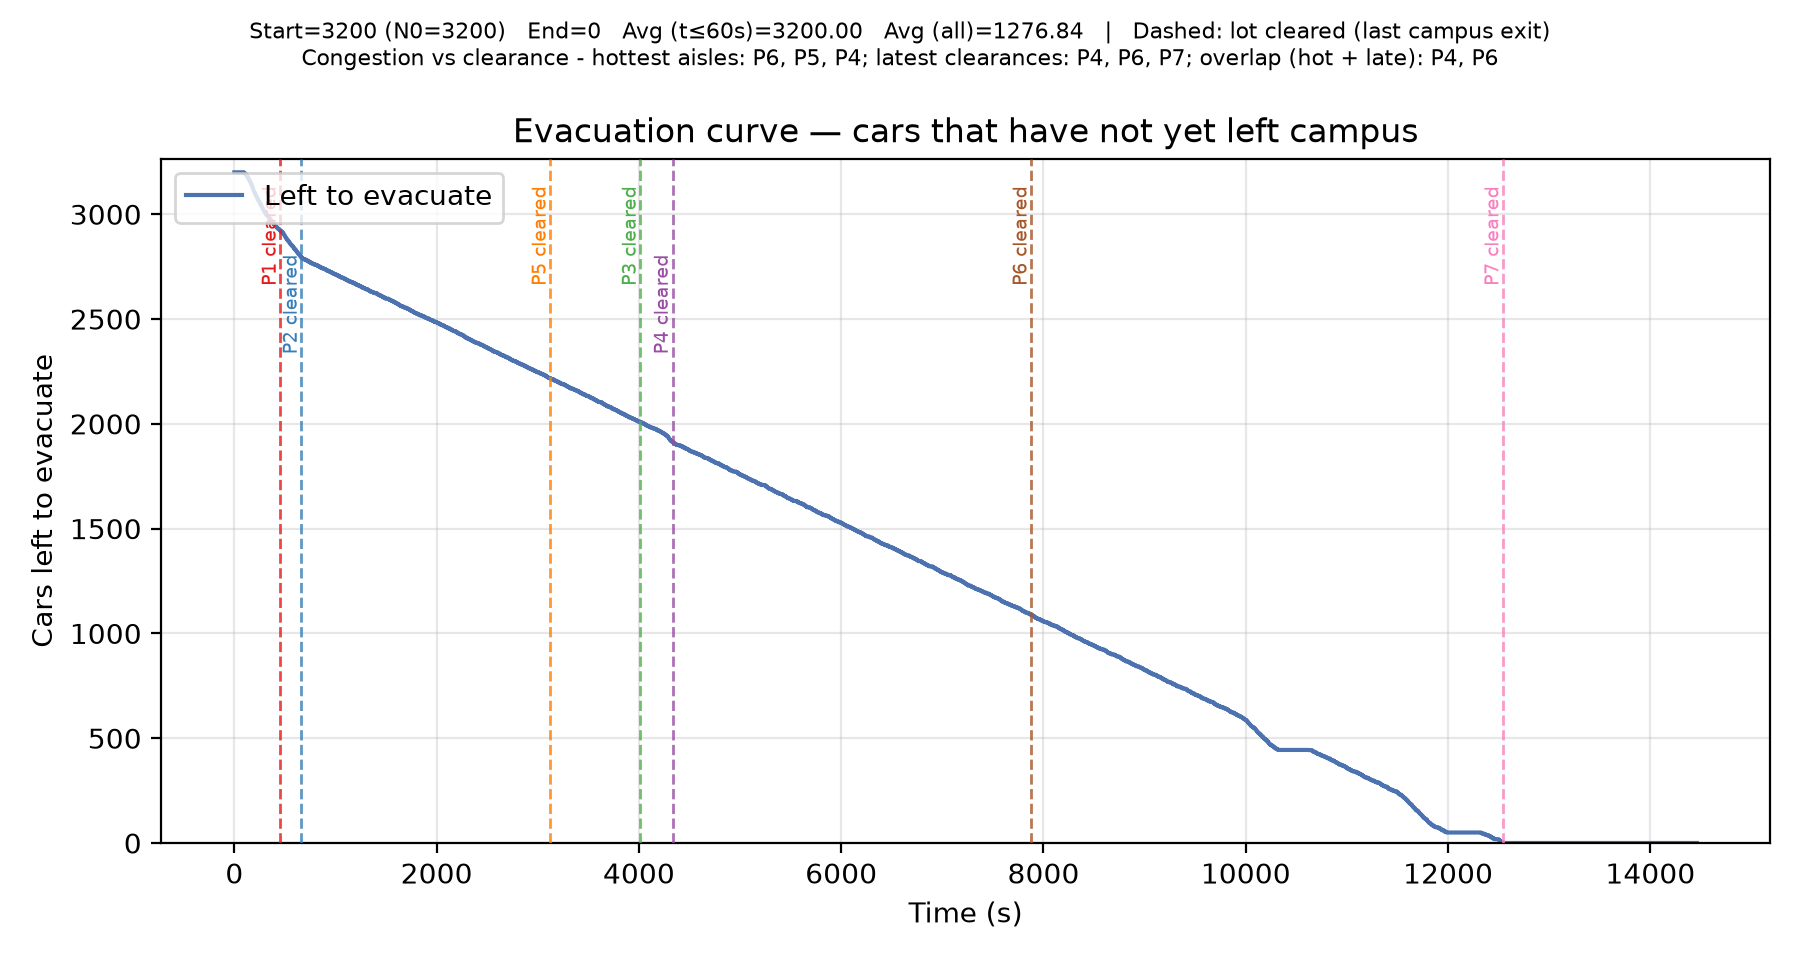

### Travel-time summary

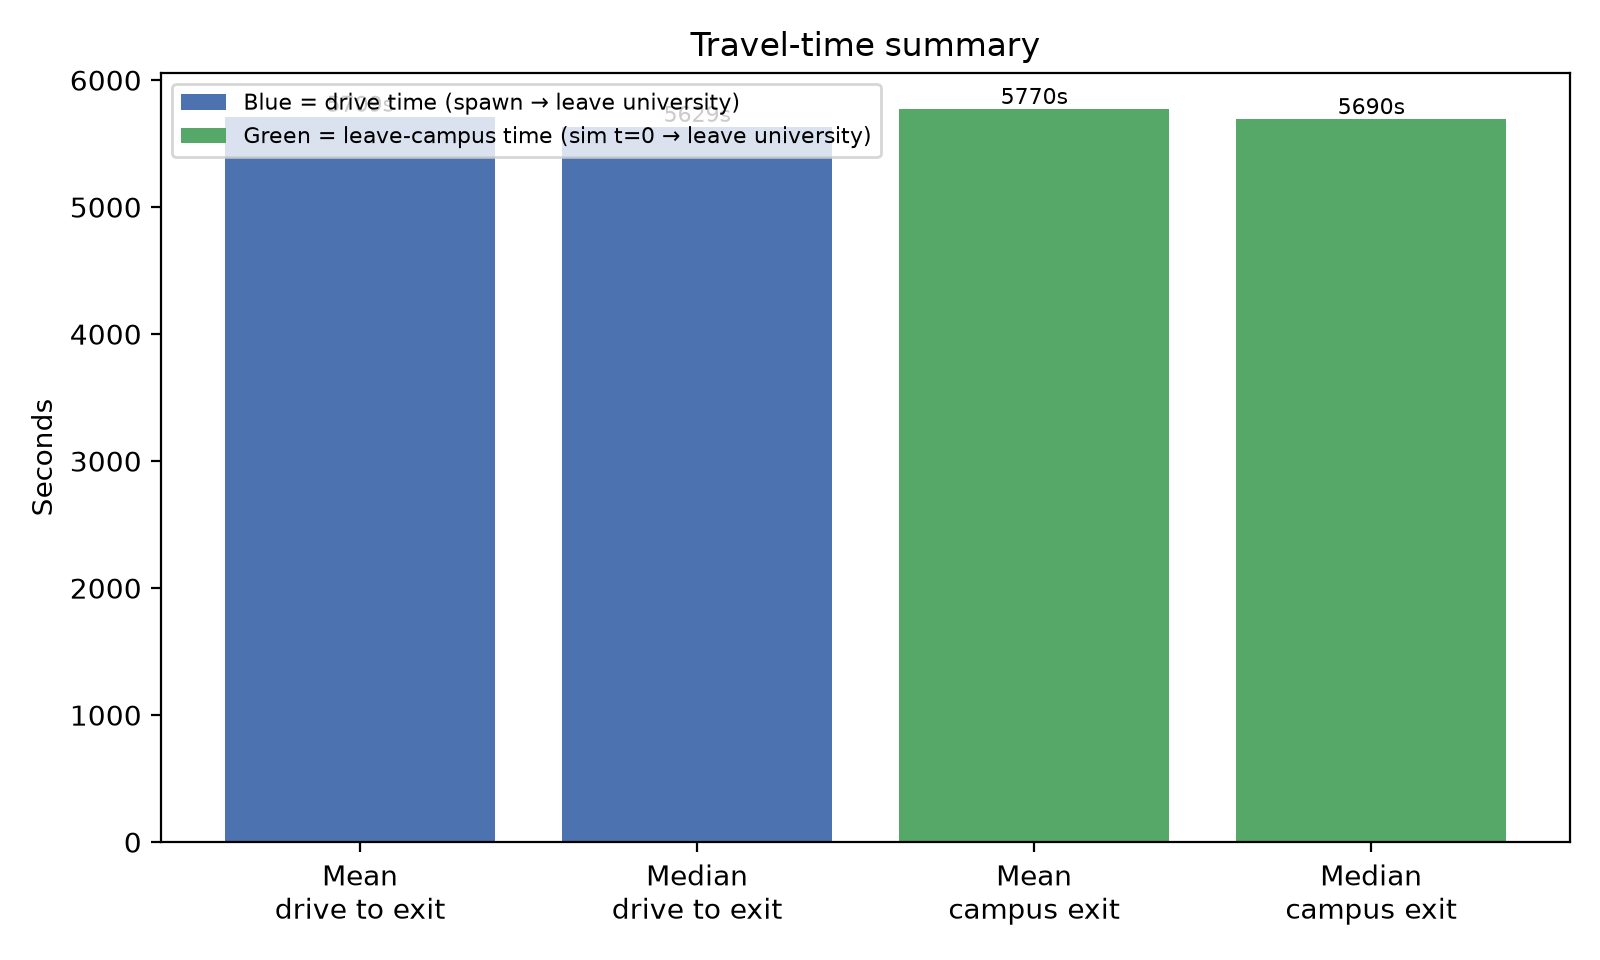

### Travel-time distribution

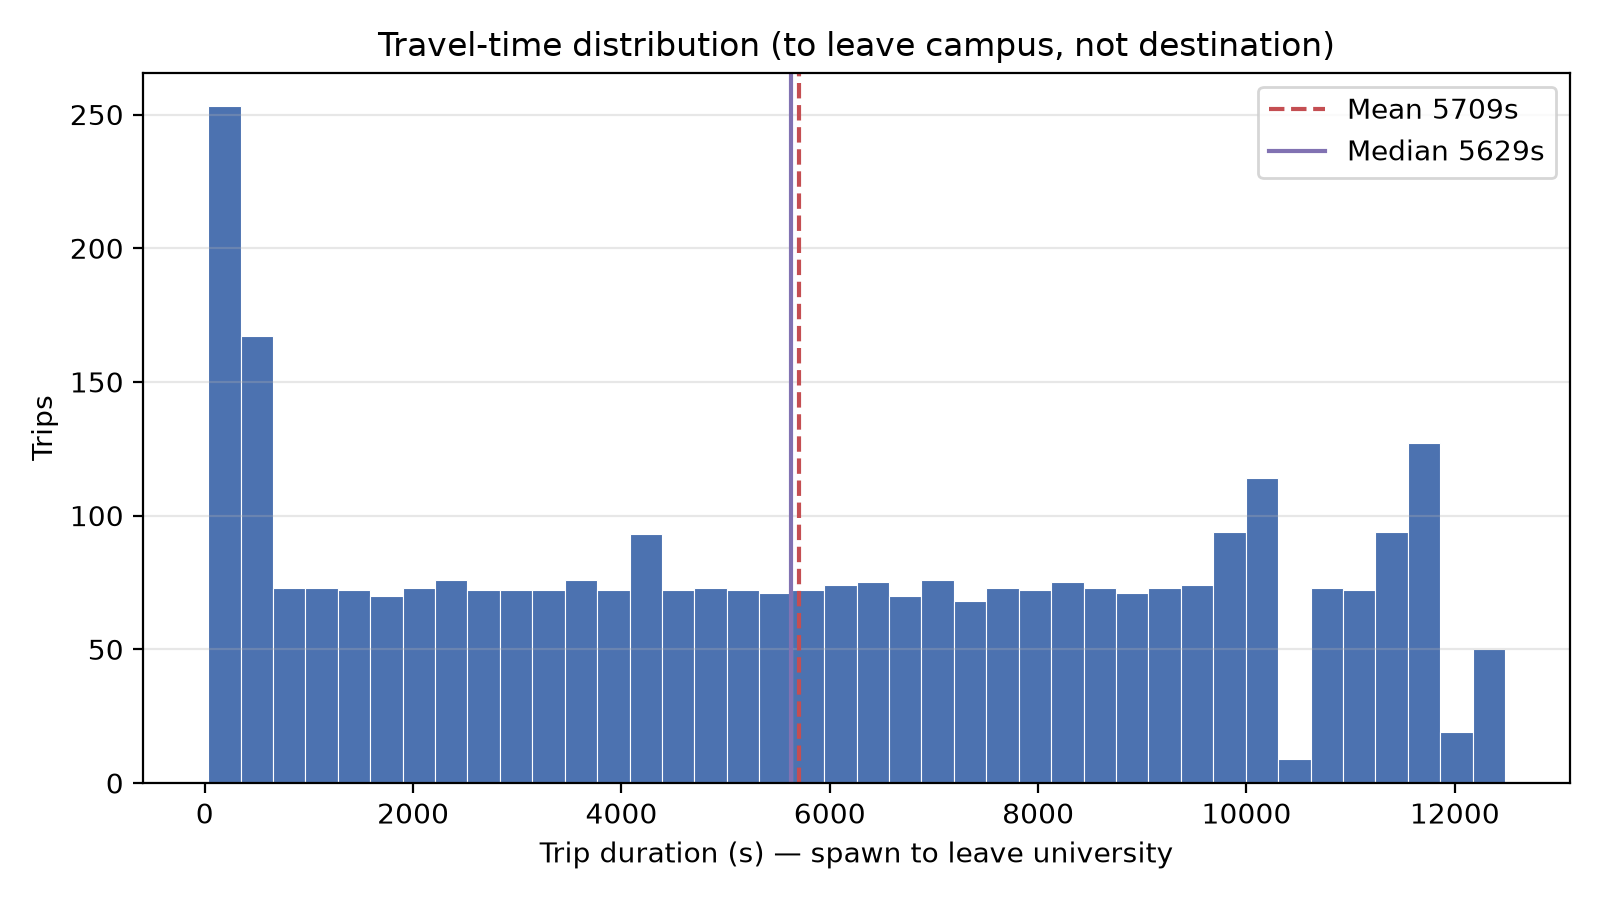

### Clearance by lot

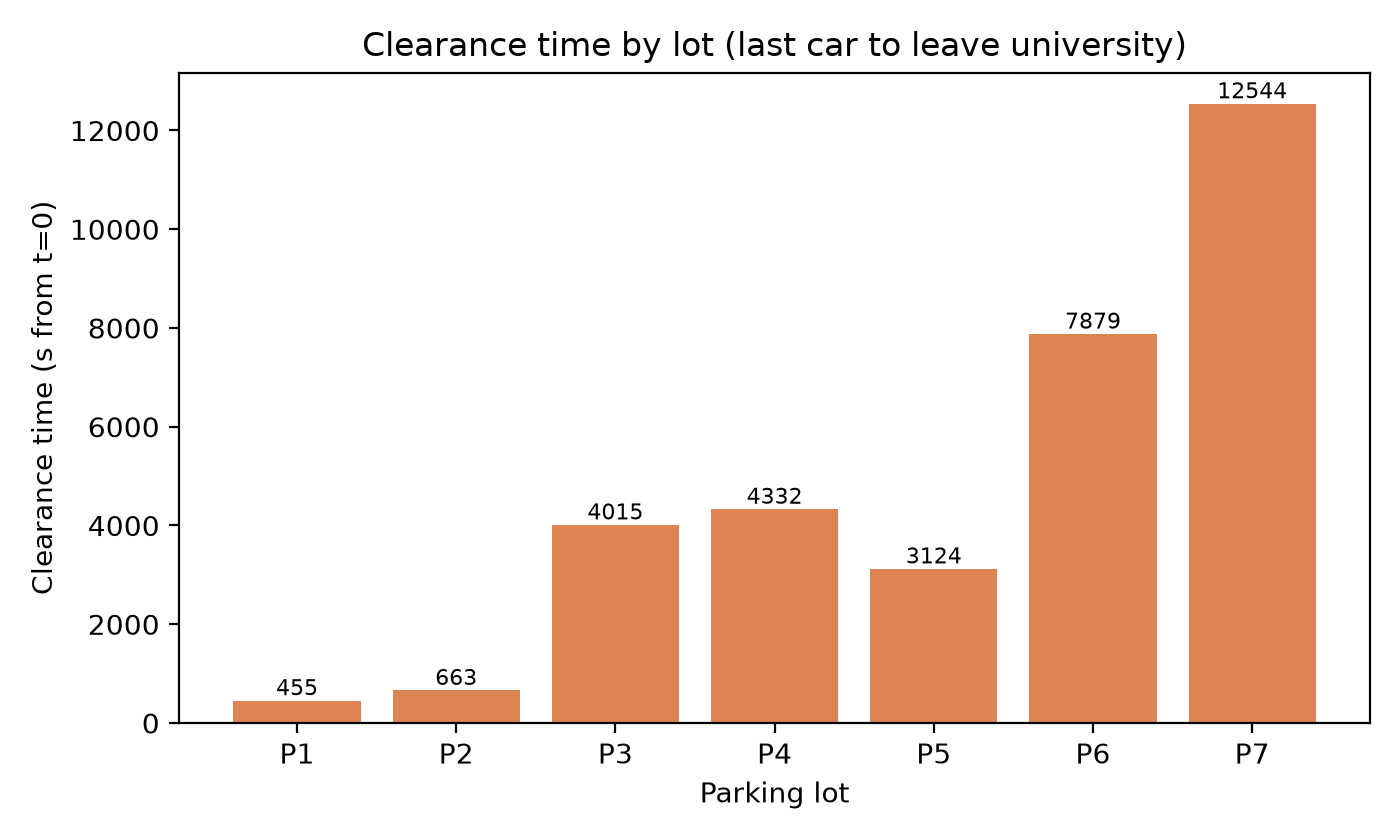

### Per-lot completion

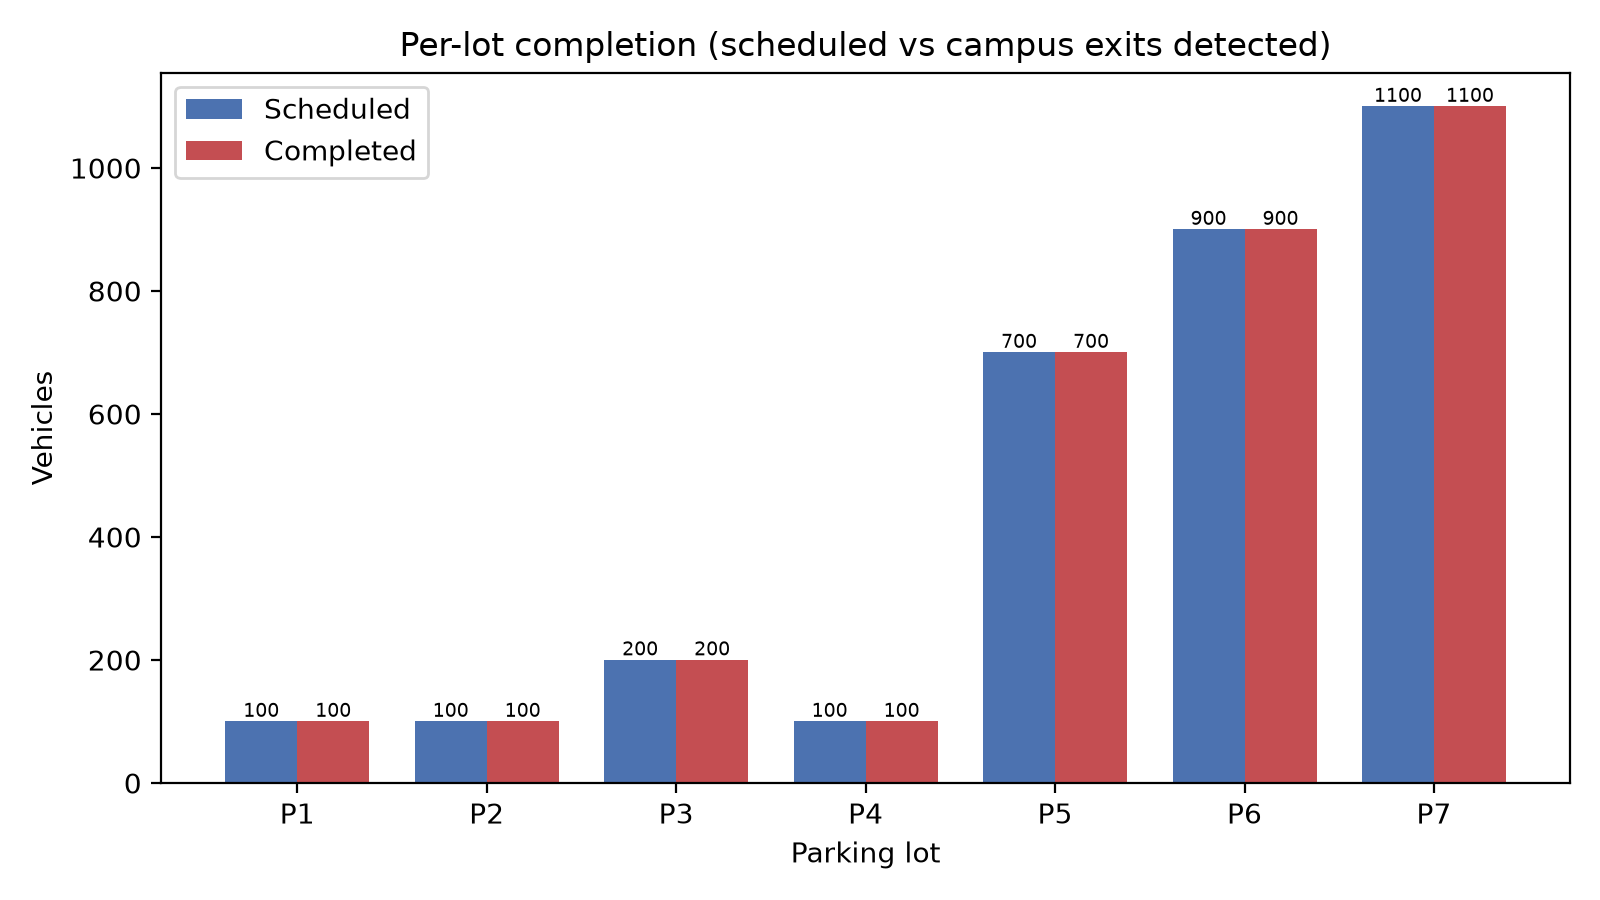

### Exit usage

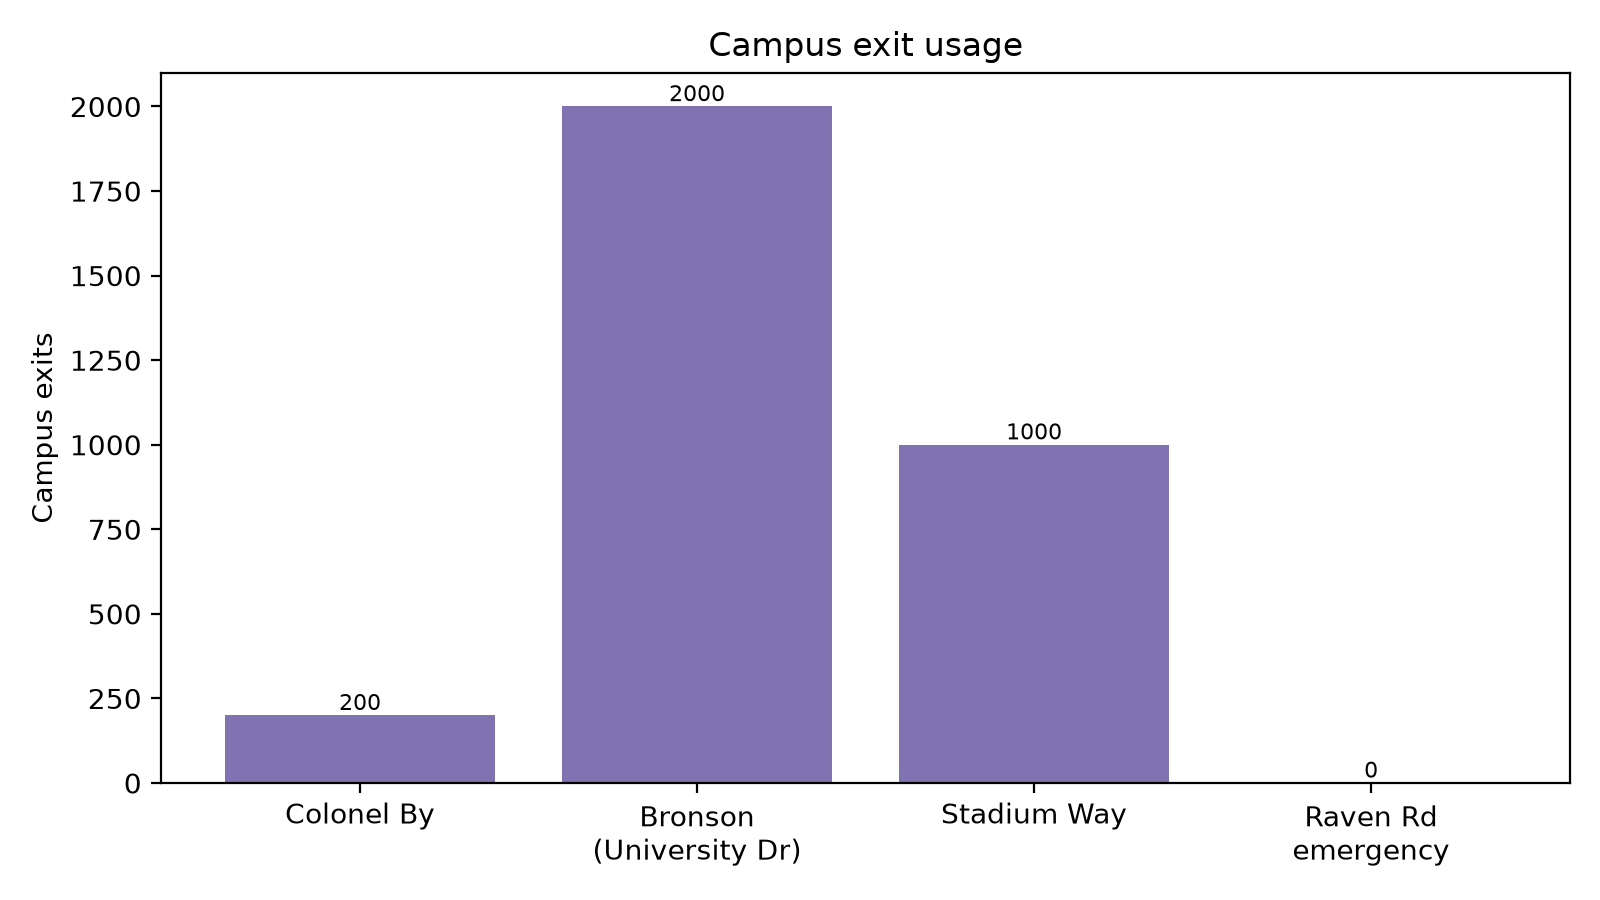

### Congestion heatmap (all campus roads)

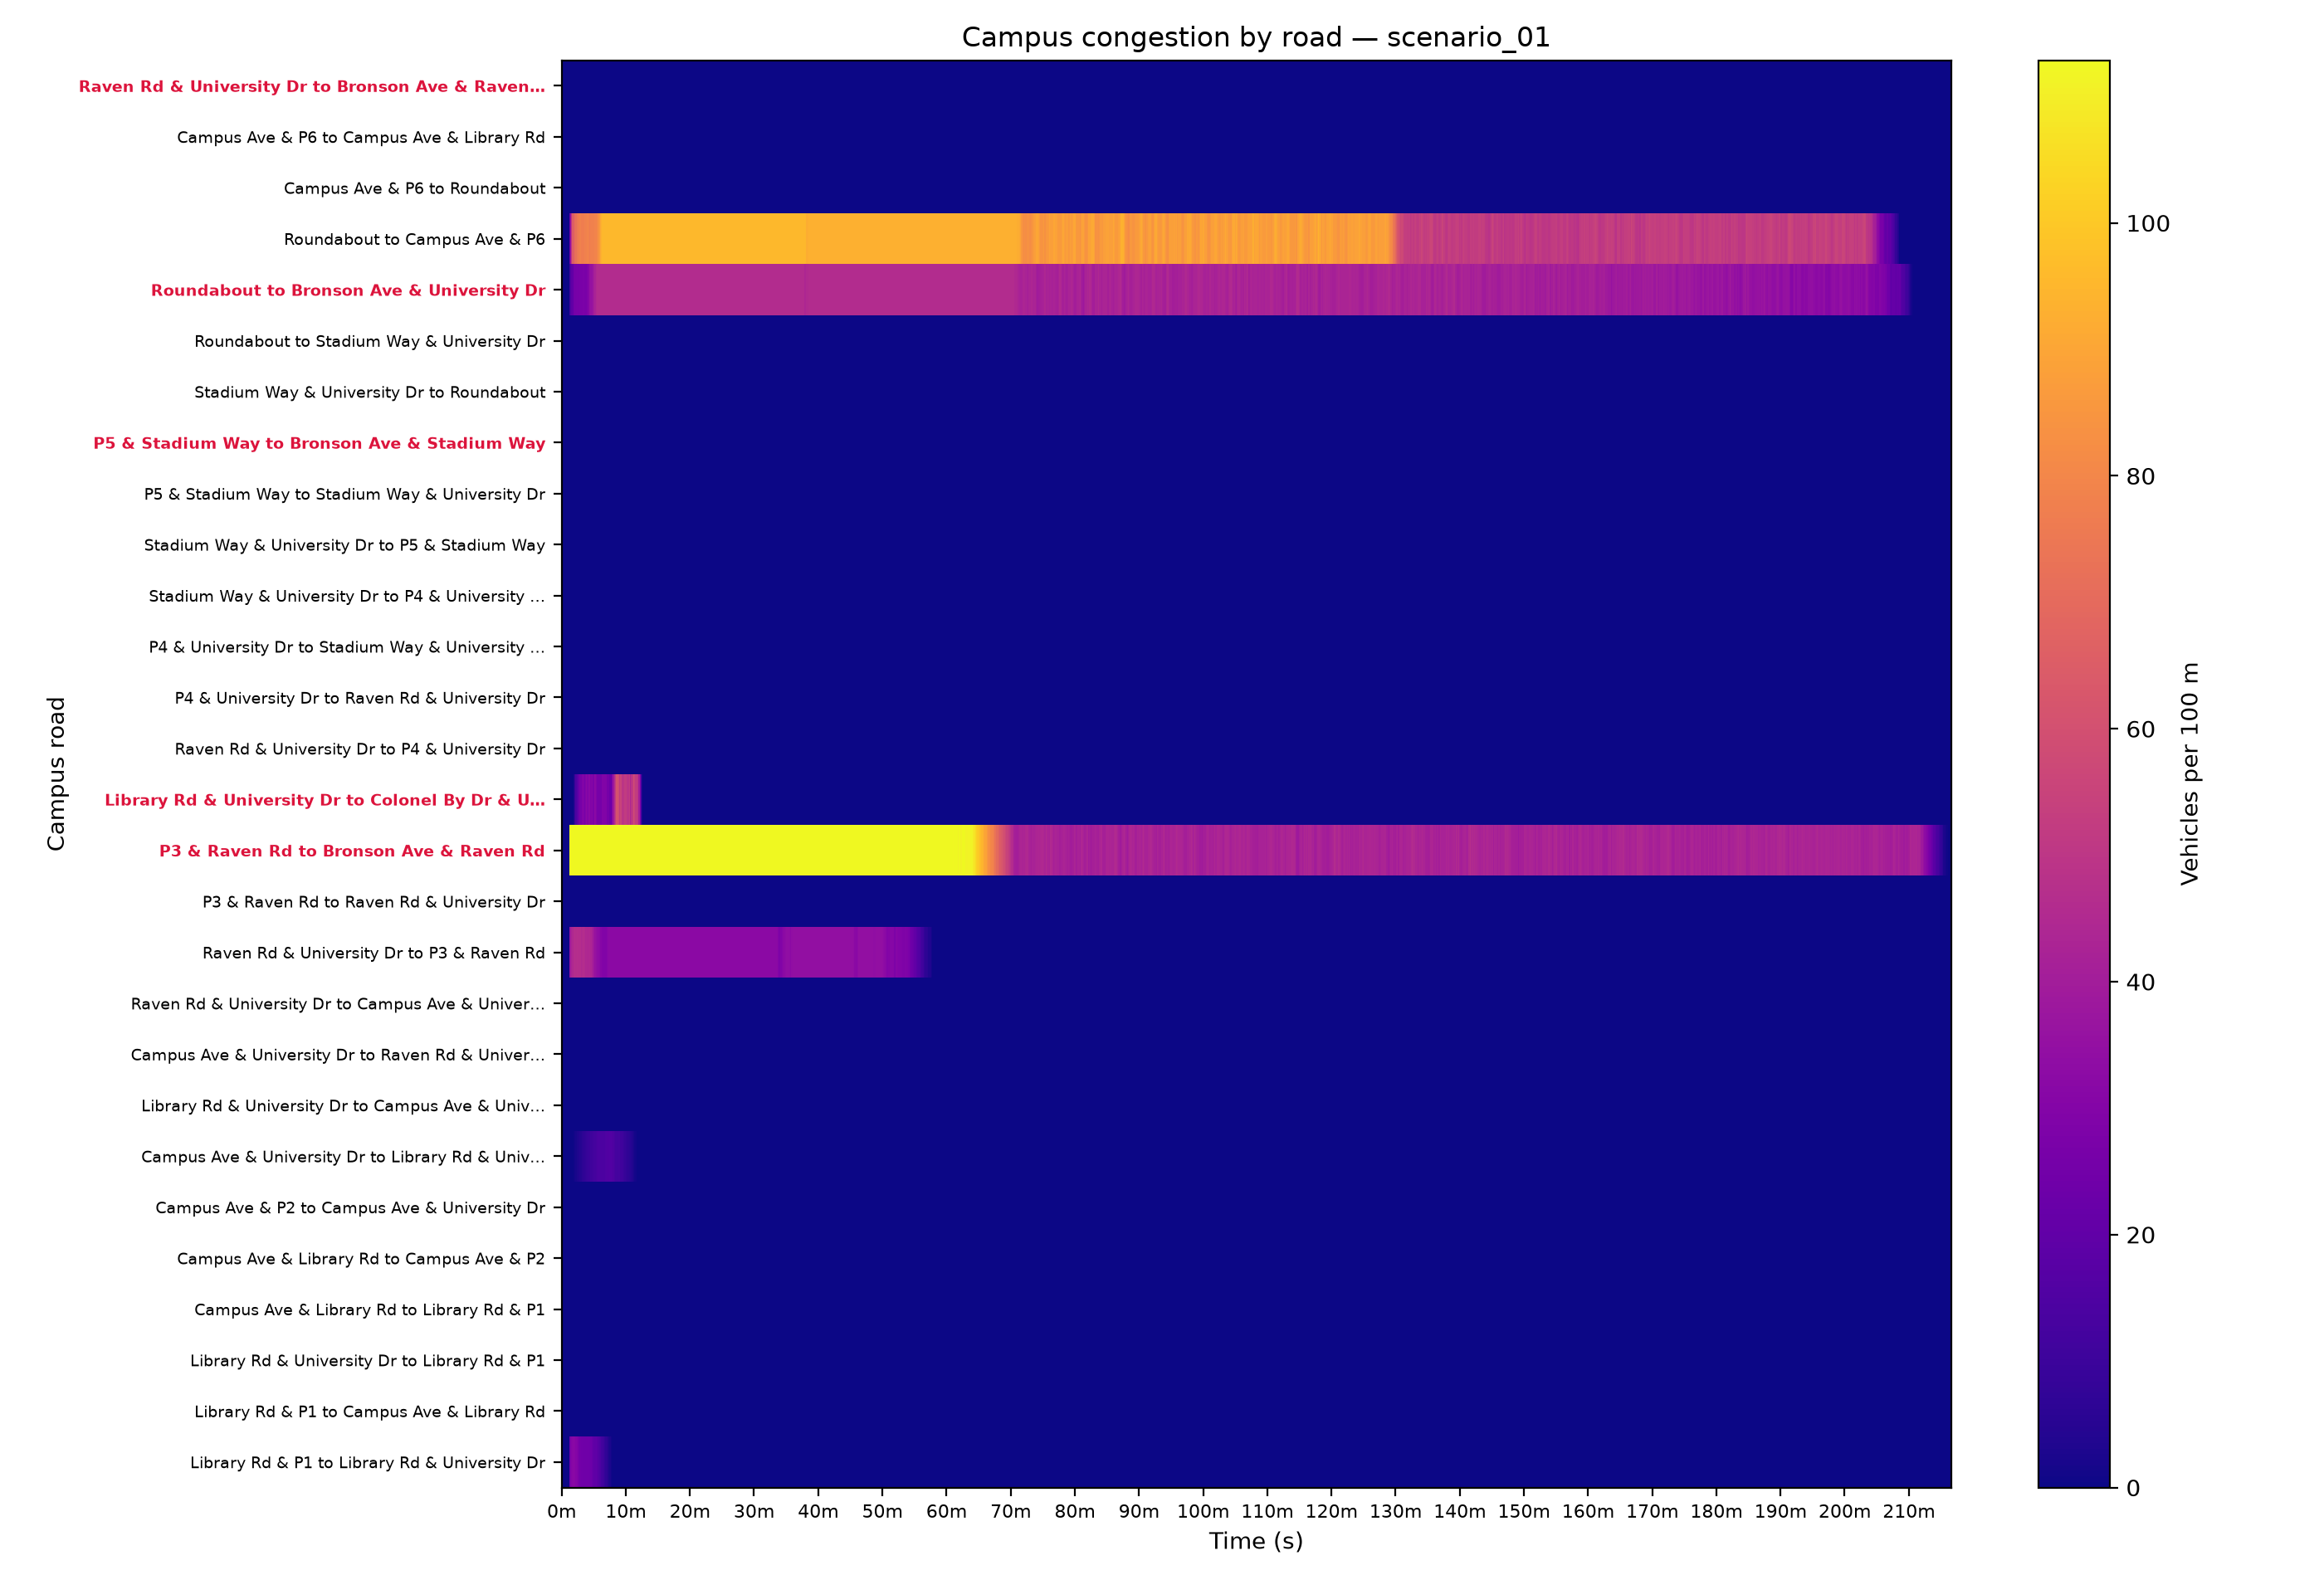

### Hottest corridors

road,peak_cars_in_sample,length_m,peak_cars_per_100m
Library Rd & P1 to Library Rd & University Dr,65,204.28,31.819
Library Rd & P1 to Campus Ave & Library Rd,0,699.85,0.0
Library Rd & University Dr to Library Rd & P1,0,204.28,0.0
Campus Ave & Library Rd to Library Rd & P1,0,699.85,0.0
Campus Ave & Library Rd to Campus Ave & P2,0,179.53,0.0
Campus Ave & P2 to Campus Ave & University Dr,0,166.12,0.0
Campus Ave & University Dr to Library Rd & University Dr,84,516.86,16.252
Library Rd & University Dr to Campus Ave & University Dr,0,516.86,0.0
Campus Ave & University Dr to Raven Rd & University Dr,0,310.06,0.0
Raven Rd & University Dr to Campus Ave & University Dr,0,310.06,0.0
Raven Rd & University Dr to P3 & Raven Rd,87,185.44,46.916
P3 & Raven Rd to Raven Rd & University Dr,0,185.44,0.0
P3 & Raven Rd to Bronson Ave & Raven Rd,449,132.91,337.819
Library Rd & University Dr to Colonel By Dr & University Dr,21,34.36,61.12
Raven Rd & University Dr to P4 & University Dr,0,202.6,0.0
P4 & Univer

In [46]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(f"No CSV at {CSV_PATH}. Set RUN_SIMULATION = True and re-run.")

if not RUN_ANALYZE and not RUN_HEATMAP:
    print("Neither RUN_ANALYZE nor RUN_HEATMAP is True — nothing to build.")

if RUN_ANALYZE:
    run_cmd([sys.executable, str(SCRIPTS / "analyze_run.py"), str(CSV_PATH)])

if RUN_HEATMAP:
    matrix = OUT_DIR / "heatmap_matrix.csv"
    run_cmd([
        sys.executable,
        str(SCRIPTS / "build_heatmap_matrix.py"),
        str(CSV_PATH),
        "--dt",
        "10",
    ])
    run_cmd([
        sys.executable,
        str(SCRIPTS / "plot_heatmap.py"),
        str(matrix)
    ])

if RUN_ANALYZE:
    summary_csv = OUT_DIR / "summary.csv"
    if summary_csv.is_file():
        display(Markdown("### Summary"))
        print(summary_csv.read_text(encoding="utf-8"))

    metrics_json = OUT_DIR / "metrics.json"
    if metrics_json.is_file():
        display(Markdown("### metrics.json"))
        print(metrics_json.read_text(encoding="utf-8")[:2000])

    breakdowns_csv = OUT_DIR / "breakdowns.csv"
    if breakdowns_csv.is_file():
        display(Markdown("### Breakdowns"))
        print(breakdowns_csv.read_text(encoding="utf-8"))

    for name, title in {
        "summary.png": "### Deployment",
        "evac_curve.png": "### Evacuation curve",
        "trip_time_stats.png": "### Travel-time summary",
        "trip_time_hist.png": "### Travel-time distribution",
        "clearance_by_lot.png": "### Clearance by lot",
        "completion_by_lot.png": "### Per-lot completion",
        "exit_usage.png": "### Exit usage",
    }.items():
        path = OUT_DIR / name
        if path.is_file():
            display(Markdown(title))
            display(Image(filename=str(path)))
        else:
            print(f"Missing chart: {name}")

if RUN_HEATMAP:
    heat_png = OUT_DIR / "heatmap_matrix.png"
    peaks = OUT_DIR / "heatmap_road_peaks.csv"
    if heat_png.is_file():
        display(Markdown("### Congestion heatmap (all campus roads)"))
        display(Image(filename=str(heat_png)))
    else:
        print("Missing chart: heatmap_matrix.png")
    if peaks.is_file():
        display(Markdown("### Hottest corridors"))
        print(peaks.read_text(encoding="utf-8"))


**Step 5** — Plot one sample route per parking lot (P1–P7) to its campus exit.

Writes `results/scenario_XX/agent_routes/P*_to_exit.png`. Skipped when `RUN_ROUTES = False`.

Plotting one route per lot (P1–P7)…


### P1 → exit

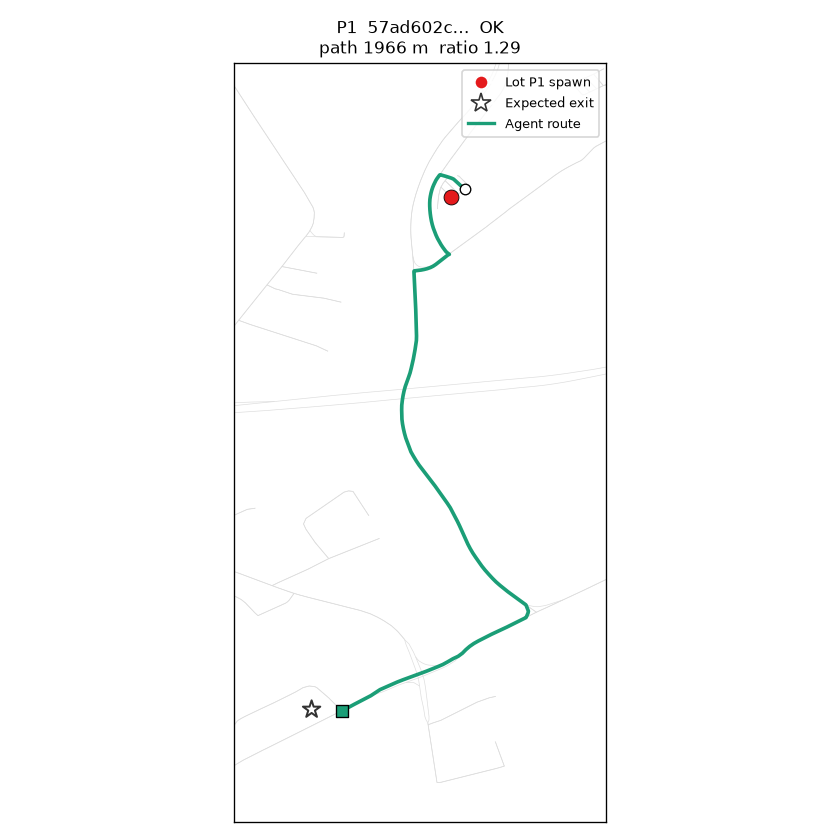

### P2 → exit

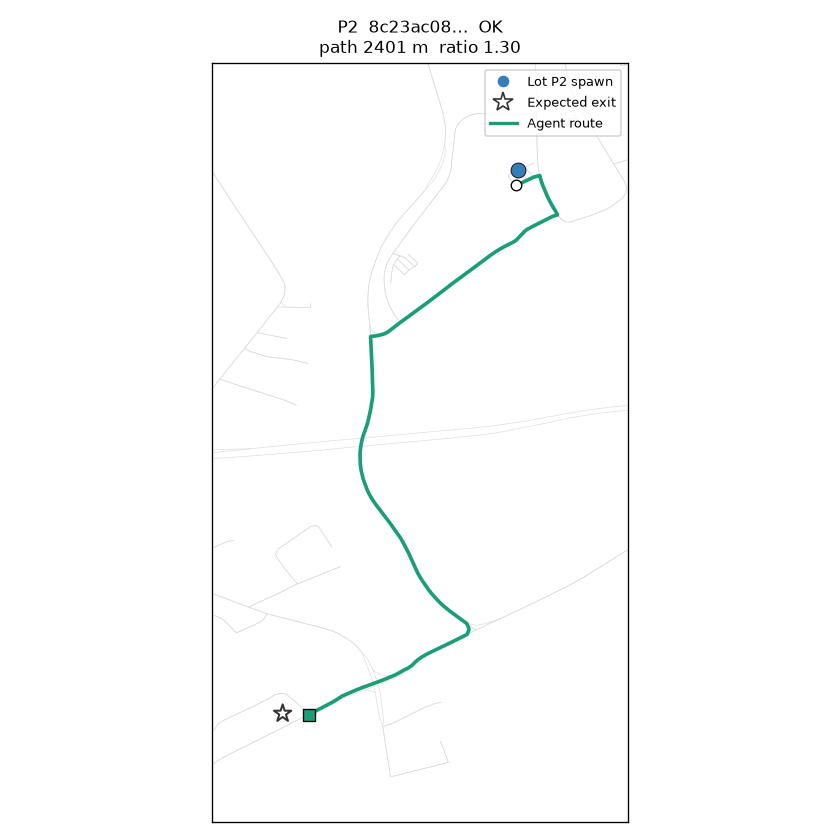

### P3 → exit

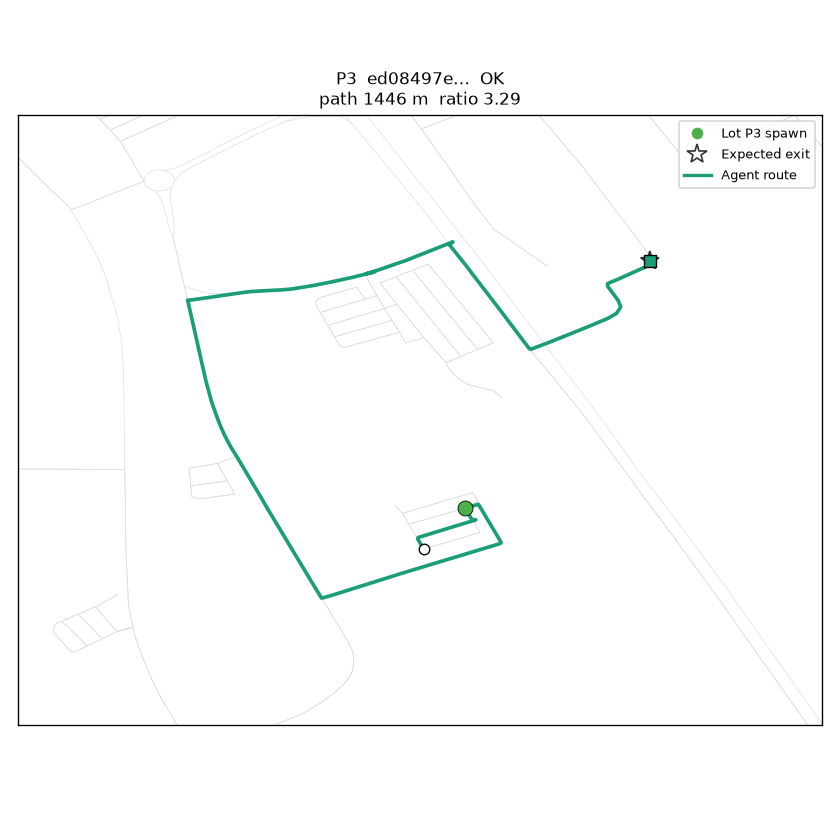

### P4 → exit

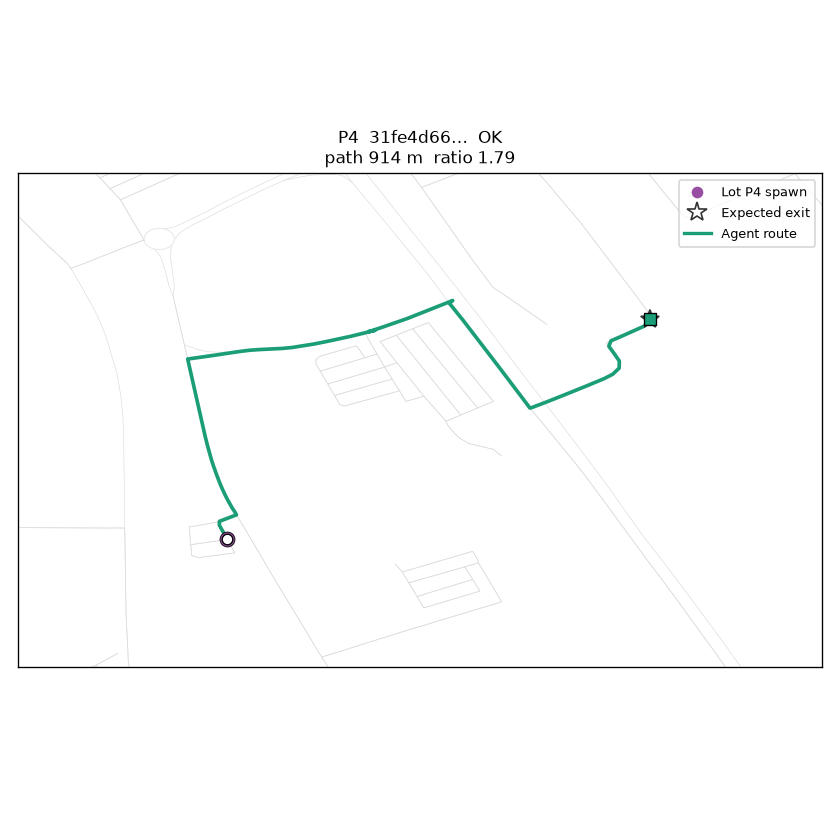

### P5 → exit

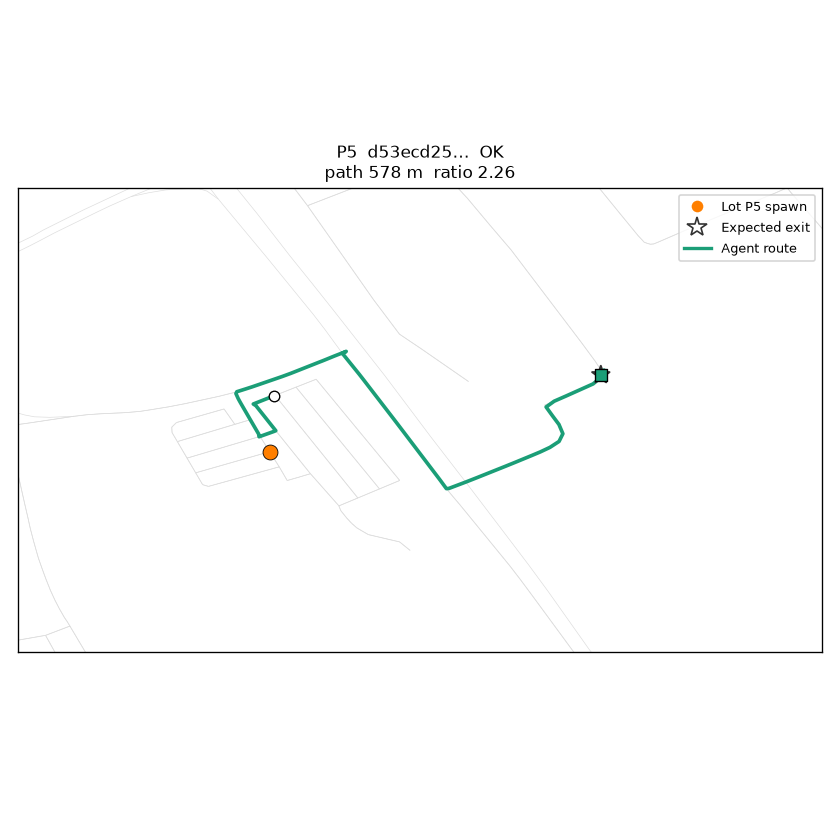

### P6 → exit

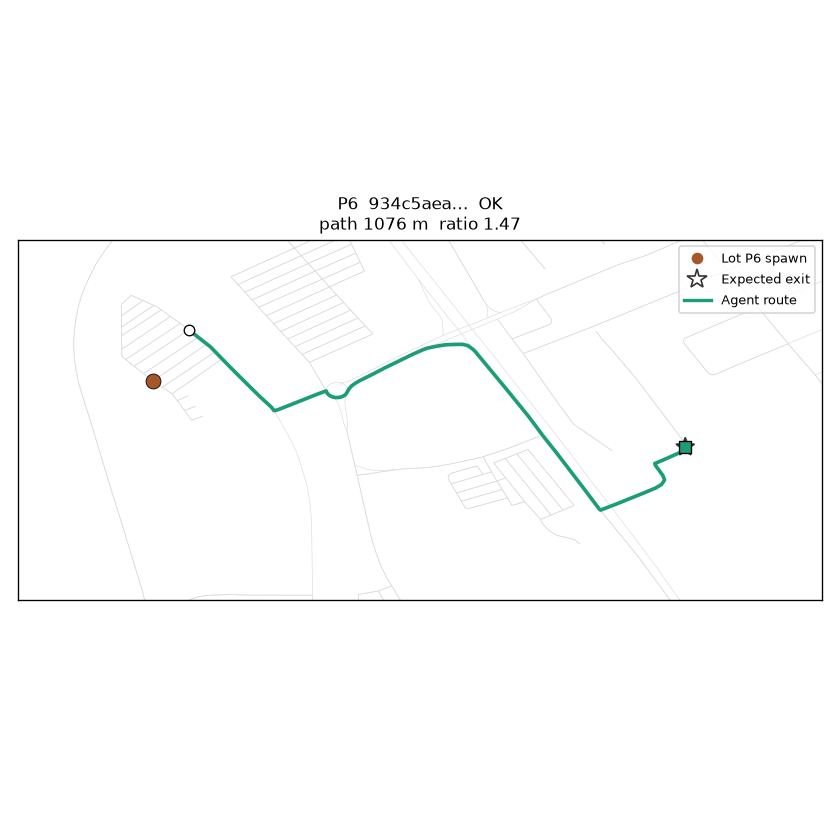

### P7 → exit

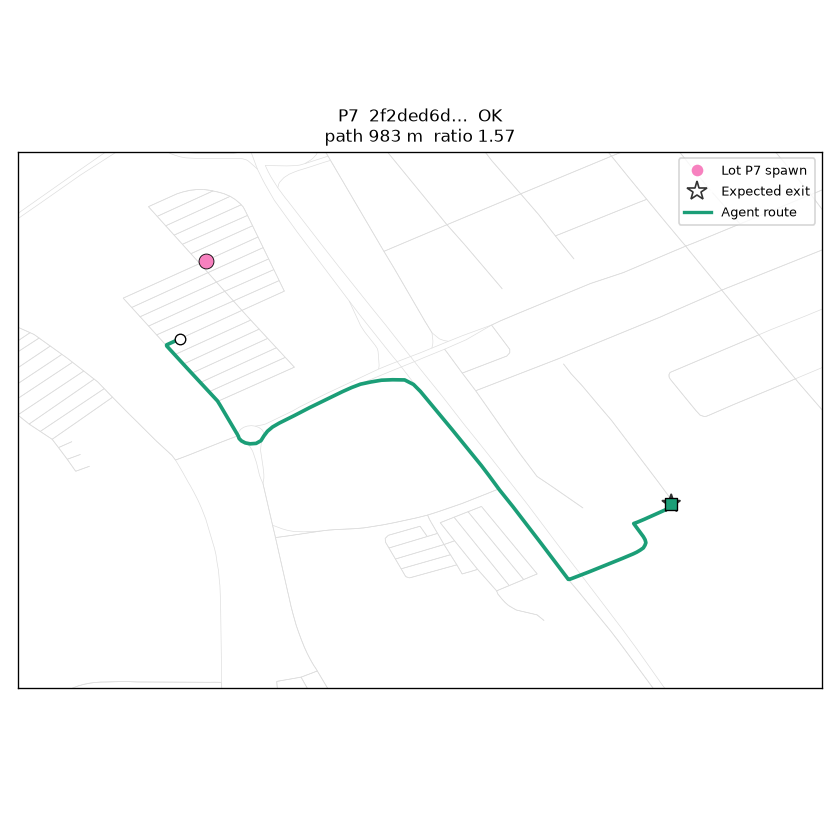

In [25]:
if RUN_ROUTES:
    run_cmd(
        [
            sys.executable,
            str(SCRIPTS / "plot_agent_routes.py"),
            SID,
            "--one-per-lot",
        ],
        label="Plotting one route per lot (P1–P7)…",
    )
    for lot in ["P1", "P2", "P3", "P4", "P5", "P6", "P7"]:
        path = ROUTES_DIR / f"{lot}_to_exit.png"
        if path.is_file():
            display(Markdown(f"### {lot} → exit"))
            display(Image(filename=str(path)))
        else:
            print(f"Missing route plot: {path.name}")
else:
    print("Route plots skipped (RUN_ROUTES is False).")